# CIFAR10 with CNNs
Simple starter notebook to benchmark your own CNN with PyTorch on the CIFAR-10 dataset.

OBS.:

- The main code is basically done, so focus on training the models and searching for the best hyperparameters and architectures.
- You are not required to use this exact code or even the PyTorch library.
- It is recommended to use execution environments with GPU access (such as Google Colab), since larger models will take more time to train.
- Remember to document the history of your experiments and which results motivated the changes in subsequent experiments.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
pip install optuna -q

In [14]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm

import optuna
from sklearn.model_selection import KFold, train_test_split
from torch.utils.data import DataLoader, Subset

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda


In [16]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)


In [17]:
subset_size = 10000 # subconjunto pra ir mais rápido

train_indices = list(range(len(train_dataset)))
train_labels = [train_dataset[i][1] for i in train_indices]

search_indices, _ = train_test_split(
    train_indices,
    train_size=subset_size,
    stratify=train_labels, # garante a mesma quantidade por classe
    random_state=42
)

search_dataset = Subset(train_dataset, search_indices) # só no optuna

print(f"Subconjunto de busca criado com {len(search_dataset)} imagens.")
print(f"Representa {len(search_dataset)//10} imagens por classe.")

Subconjunto de busca criado com 10000 imagens.
Representa 1000 imagens por classe.


In [18]:
def final_evaluation_cnn(best_model, test_loader):
    best_model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = best_model(images)
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\nRelatório de Classificação Final:")
    print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.title('Matriz de Confusão - CNN')
    plt.show()

In [22]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, input_shape, block_configs, fc_sizes, dropout_rate, activation_func,
                 conv_kernel_size=3, conv_stride=1, conv_padding=1, pool_kernel_size=2):
        super(CNN, self).__init__()

        layers = []
        in_channels = input_shape[0]

        for num_convs, out_channels in block_configs:
            for i in range(num_convs):
                layers.append(nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=conv_kernel_size,
                    stride=conv_stride,
                    padding=conv_padding
                ))

                if i == 0:
                    layers.append(nn.BatchNorm2d(out_channels))

                layers.append(activation_func)
                in_channels = out_channels

            layers.append(nn.MaxPool2d(kernel_size=pool_kernel_size))
            layers.append(nn.Dropout2d(dropout_rate))

        self.features = nn.Sequential(*layers)

        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            try:
                dummy_output = self.features(dummy_input)
                flattened_size = dummy_output.numel()
            except RuntimeError as e:
                raise ValueError(f"As configurações encolheram a dimensão espacial a zero ou menos. Erro: {e}")

        fc_layers = []
        in_f = flattened_size
        for h_size in fc_sizes:
            fc_layers.append(nn.Linear(in_f, h_size))
            fc_layers.append(activation_func)
            fc_layers.append(nn.Dropout(dropout_rate))
            in_f = h_size

        fc_layers.append(nn.Linear(in_f, 10))
        self.classifier = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [26]:
def objective_cnn(trial):
    # Ex: [(3, 64)] significa um bloco com 3 convoluções de 64 filtros
    arch_styles = {
        "Simples": [(2, 32), (2, 64)],
        "Intermediaria": [(2, 64), (2, 128), (2, 256)],
        "Avancada_VGG": [(3, 64), (3, 128), (3, 256)],
        "Profunda": [(2, 64), (2, 128), (3, 256), (3, 512)]
    }

    style_name = trial.suggest_categorical("arch_style", list(arch_styles.keys()))
    block_configs = arch_styles[style_name]

    # escolha dinâmica das camadas densas (FC)
    n_fc_layers = trial.suggest_int("n_fc_layers", 1, 2)
    fc_sizes = [trial.suggest_categorical(f"fc_size_l{i}", [512, 1024, 2048]) for i in range(n_fc_layers)]

    conv_kernel_size = trial.suggest_categorical("conv_kernel_size", [3, 5])
    conv_padding = conv_kernel_size // 2
    conv_stride = 1
    pool_kernel_size = 2

    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    activation_name = trial.suggest_categorical("activation", ["ReLU", "LeakyReLU", "Tanh"])
    activations = {"ReLU": nn.ReLU(), "LeakyReLU": nn.LeakyReLU(), "Tanh": nn.Tanh()}

    input_shape = search_dataset[0][0].shape
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f"\n[Trial #{trial.number}] Estilo: {style_name} | FC: {fc_sizes} | Opt: {optimizer_name}")

    k_folds = 3
    kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    fold_accuracies = []

    for fold, (train_ids, val_ids) in enumerate(kfold.split(search_dataset)):
        train_loader = DataLoader(Subset(search_dataset, train_ids), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(Subset(search_dataset, val_ids), batch_size=batch_size, shuffle=False)

        try:
            model = CNN(
                input_shape=input_shape,
                block_configs=block_configs,
                fc_sizes=fc_sizes,
                dropout_rate=dropout_rate,
                activation_func=activations[activation_name],
                conv_kernel_size=conv_kernel_size,
                conv_stride=conv_stride,
                conv_padding=conv_padding,
                pool_kernel_size=pool_kernel_size
            ).to(device)
        except ValueError as e:
            print(f" Trial podada por incompatibilidade dimensional: {e}")
            raise optuna.exceptions.TrialPruned()

        optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(5):
            model.train()
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                pred = outputs.argmax(dim=1)
                correct += pred.eq(labels).sum().item()
                total += labels.size(0)

        fold_accuracies.append(correct / total)

    mean_acc = np.mean(fold_accuracies)
    print(f"Trial {trial.number} finalizado. Acurácia Média: {mean_acc:.4f}")
    return mean_acc

In [28]:
study_cnn = optuna.create_study(direction="maximize")
study_cnn.optimize(objective_cnn, n_trials=100)

print(f"\nMelhor Acurácia de Validação CNN: {study_cnn.best_value:.4f}")
print(f"Melhores Parâmetros CNN: {study_cnn.best_params}")

[I 2026-04-06 01:38:35,726] A new study created in memory with name: no-name-a49c637f-a011-4110-81bc-e5a480d5a628



[Trial #0] Estilo: Intermediaria | FC: [1024, 1024] | Opt: SGD


[I 2026-04-06 01:39:58,395] Trial 0 finished with value: 0.10160044198781006 and parameters: {'arch_style': 'Intermediaria', 'n_fc_layers': 2, 'fc_size_l0': 1024, 'fc_size_l1': 1024, 'conv_kernel_size': 5, 'lr': 1.2534007231706259e-05, 'weight_decay': 1.2308032389012704e-06, 'dropout': 0.18560284391421777, 'batch_size': 128, 'optimizer': 'SGD', 'activation': 'Tanh'}. Best is trial 0 with value: 0.10160044198781006.


Trial 0 finalizado. Acurácia Média: 0.1016

[Trial #1] Estilo: Intermediaria | FC: [512] | Opt: Adam


[I 2026-04-06 01:40:30,146] Trial 1 finished with value: 0.5289994806319265 and parameters: {'arch_style': 'Intermediaria', 'n_fc_layers': 1, 'fc_size_l0': 512, 'conv_kernel_size': 3, 'lr': 0.00013614835379306502, 'weight_decay': 1.590658530433742e-06, 'dropout': 0.33042429186979005, 'batch_size': 64, 'optimizer': 'Adam', 'activation': 'Tanh'}. Best is trial 1 with value: 0.5289994806319265.


...

Trial 97 finalizado. Acurácia Média: 0.1825

[Trial #98] Estilo: Intermediaria | FC: [2048] | Opt: Adam


[I 2026-04-06 02:57:35,484] Trial 98 finished with value: 0.5947999718988096 and parameters: {'arch_style': 'Intermediaria', 'n_fc_layers': 1, 'fc_size_l0': 2048, 'conv_kernel_size': 3, 'lr': 8.135396806328293e-05, 'weight_decay': 5.748466107470507e-05, 'dropout': 0.1876658878101908, 'batch_size': 32, 'optimizer': 'Adam', 'activation': 'LeakyReLU'}. Best is trial 94 with value: 0.6217987125647176.


Trial 98 finalizado. Acurácia Média: 0.5948

[Trial #99] Estilo: Simples | FC: [2048] | Opt: Adam


[I 2026-04-06 02:58:11,477] Trial 99 finished with value: 0.5589000411738835 and parameters: {'arch_style': 'Simples', 'n_fc_layers': 1, 'fc_size_l0': 2048, 'conv_kernel_size': 3, 'lr': 9.68125673973016e-05, 'weight_decay': 7.607921165173391e-05, 'dropout': 0.19647357757258965, 'batch_size': 32, 'optimizer': 'Adam', 'activation': 'LeakyReLU'}. Best is trial 94 with value: 0.6217987125647176.


Trial 99 finalizado. Acurácia Média: 0.5589

Melhor Acurácia de Validação CNN: 0.6218
Melhores Parâmetros CNN: {'arch_style': 'Intermediaria', 'n_fc_layers': 1, 'fc_size_l0': 2048, 'conv_kernel_size': 3, 'lr': 0.0001433244131608313, 'weight_decay': 6.232804642200883e-05, 'dropout': 0.16856937633499902, 'batch_size': 32, 'optimizer': 'Adam', 'activation': 'ReLU'}


In [29]:
best_params = study_cnn.best_params

arch_styles = {
    "Simples": [(2, 32), (2, 64)],
    "Intermediaria": [(2, 64), (2, 128), (2, 256)],
    "Avancada_VGG": [(3, 64), (3, 128), (3, 256)],
    "Profunda": [(2, 64), (2, 128), (3, 256), (3, 512)]
}

activations = {
    "ReLU": nn.ReLU(),
    "LeakyReLU": nn.LeakyReLU(),
    "Tanh": nn.Tanh()
}

best_block_configs = arch_styles[best_params["arch_style"]]
best_activation = activations[best_params["activation"]]

fc_sizes = []
for i in range(best_params["n_fc_layers"]):
    fc_sizes.append(best_params[f"fc_size_l{i}"])

input_shape = train_dataset[0][0].shape

print(f"\nTreinando o modelo FINAL: {best_params['arch_style']}")
print(f"Configuração FC: {fc_sizes} | LR: {best_params['lr']:.6f}")

best_k_size = best_params["conv_kernel_size"]
best_padding = best_k_size // 2

best_cnn_model = CNN(
    input_shape=input_shape,
    block_configs=best_block_configs,
    fc_sizes=fc_sizes,
    dropout_rate=best_params["dropout"],
    activation_func=best_activation,
    conv_kernel_size=best_k_size,
    conv_stride=1,
    conv_padding=best_padding,
    pool_kernel_size=2
).to(device)

optimizer = getattr(torch.optim, best_params["optimizer"])(
    best_cnn_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

full_train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
criterion = nn.CrossEntropyLoss()

best_loss = float('inf')
patience = 7
patience_counter = 0
max_epochs = 100
best_model_path = '/content/drive/MyDrive/melhor_modelo_cnn_final.pth'

for epoch in range(max_epochs):
    best_cnn_model.train()
    epoch_loss = 0.0

    # tqdm para barra de progresso
    loop = tqdm(full_train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = best_cnn_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_epoch_loss = epoch_loss / len(full_train_loader)
    print(f"Época [{epoch+1}/{max_epochs}] - Loss Média: {avg_epoch_loss:.4f}")

    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience_counter = 0
        torch.save({
            'model_state_dict': best_cnn_model.state_dict(),
            'params': best_params,
            'input_shape': input_shape
        }, best_model_path)
        print(f"--> Modelo salvo com loss: {best_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly Stopping ativado na época {epoch+1}.")
            break

print("\nTreinamento finalizado!")


Treinando o modelo FINAL: Intermediaria
Configuração FC: [2048] | LR: 0.000143


Época [1/100] - Loss Média: 1.3265
--> Modelo salvo com loss: 1.3265


Época [2/100] - Loss Média: 0.8579
--> Modelo salvo com loss: 0.8579


Época [3/100] - Loss Média: 0.6702
--> Modelo salvo com loss: 0.6702


Época [4/100] - Loss Média: 0.5497
--> Modelo salvo com loss: 0.5497


...

Época [53/100] - Loss Média: 0.0341


Época [54/100] - Loss Média: 0.0317


Época [55/100] - Loss Média: 0.0321


Época [56/100] - Loss Média: 0.0308


Época [57/100] - Loss Média: 0.0311

Early Stopping ativado na época 57.

Treinamento finalizado!



Avaliação no conjunto de testes:

Relatório de Classificação Final:
              precision    recall  f1-score   support

    airplane       0.83      0.89      0.86      1000
  automobile       0.94      0.91      0.93      1000
        bird       0.83      0.73      0.78      1000
         cat       0.70      0.67      0.69      1000
        deer       0.85      0.79      0.82      1000
         dog       0.71      0.80      0.75      1000
        frog       0.89      0.89      0.89      1000
       horse       0.89      0.87      0.88      1000
        ship       0.90      0.93      0.92      1000
       truck       0.88      0.91      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



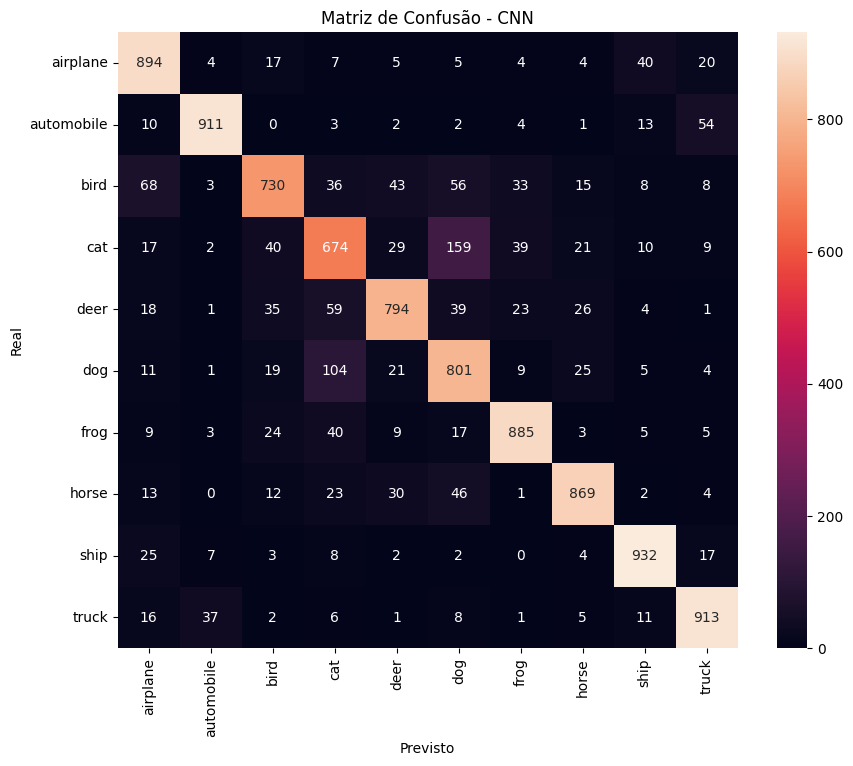

In [30]:
print("\nAvaliação no conjunto de testes:") # 0000000,,000

checkpoint = torch.load(best_model_path, map_location=device)

saved_params = checkpoint['params']
saved_input_shape = checkpoint['input_shape']

arch_styles = {
    "Simples": [(2, 32), (2, 64)],
    "Intermediaria": [(2, 64), (2, 128), (2, 256)],
    "Avancada_VGG": [(3, 64), (3, 128), (3, 256)],
    "Profunda": [(2, 64), (2, 128), (3, 256), (3, 512)]
}
activations = {"ReLU": nn.ReLU(), "LeakyReLU": nn.LeakyReLU(), "Tanh": nn.Tanh()}

best_block_configs = arch_styles[saved_params["arch_style"]]
best_activation = activations[saved_params["activation"]]
fc_sizes = [saved_params[f"fc_size_l{i}"] for i in range(saved_params["n_fc_layers"])]

saved_k_size = saved_params["conv_kernel_size"]
saved_padding = saved_k_size // 2

model_para_teste = CNN(
    input_shape=saved_input_shape,
    block_configs=best_block_configs,
    fc_sizes=fc_sizes,
    dropout_rate=saved_params["dropout"],
    activation_func=best_activation,
    conv_kernel_size=saved_k_size,
    conv_stride=1,
    conv_padding=saved_padding,
    pool_kernel_size=2
).to(device)

model_para_teste.load_state_dict(checkpoint['model_state_dict'])

test_loader = DataLoader(test_dataset, batch_size=saved_params["batch_size"], shuffle=False)
final_evaluation_cnn(model_para_teste, test_loader)

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

checkpoint = torch.load('/content/drive/MyDrive/melhor_modelo_cnn_final.pth', map_location=device)
saved_params = checkpoint['params']

arch_styles = {
    "Simples": [(2, 32), (2, 64)],
    "Intermediaria": [(2, 64), (2, 128), (2, 256)],
    "Avancada_VGG": [(3, 64), (3, 128), (3, 256)],
    "Profunda": [(2, 64), (2, 128), (3, 256), (3, 512)]
}
activations = {"ReLU": nn.ReLU(), "LeakyReLU": nn.LeakyReLU(), "Tanh": nn.Tanh()}

best_block_configs = arch_styles[saved_params["arch_style"]]
fc_sizes = [saved_params[f"fc_size_l{i}"] for i in range(saved_params["n_fc_layers"])]

saved_k_size = saved_params["conv_kernel_size"]
saved_padding = saved_k_size // 2

best_model = CNN(
    input_shape=checkpoint['input_shape'],
    block_configs=best_block_configs,
    fc_sizes=fc_sizes,
    dropout_rate=saved_params["dropout"],
    activation_func=activations[saved_params["activation"]],
    conv_kernel_size=saved_k_size,
    conv_stride=1,
    conv_padding=saved_padding,
    pool_kernel_size=2
).to(device)

best_model.load_state_dict(checkpoint['model_state_dict'])
best_model.eval()

all_preds = []
all_labels = []

test_loader = DataLoader(test_dataset, batch_size=saved_params["batch_size"], shuffle=False)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = best_model(images)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("MÉTRICAS DETALHADAS CNN (ALTA PRECISÃO)")
print("="*40)
print(f"Acurácia:  {acc:.6f}")
print(f"Precisão:  {prec:.6f} (weighted)")
print(f"Recall:    {rec:.6f} (weighted)")
print(f"F1-Score:  {f1:.6f} (weighted)")

MÉTRICAS DETALHADAS CNN (ALTA PRECISÃO)
Acurácia:  0.840300
Precisão:  0.841690 (weighted)
Recall:    0.840300 (weighted)
F1-Score:  0.840053 (weighted)


In [32]:
import optuna.visualization as vis

vis.plot_param_importances(study_cnn).show()

vis.plot_optimization_history(study_cnn).show()

vis.plot_parallel_coordinate(study_cnn).show()